# Assignment 2 — Local Binary Patterns (LBP)

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import color, data
from skimage.feature import local_binary_pattern

## 1. Compute the LBP of a given grayscale image. 
- Use the basic 8-neighbor LBP method

In [26]:
def compute_lbp(image):
    # Basic 8-neighbour LBP: compare each pixel with the 8 pixels around it.
    img = np.asarray(image, dtype=np.float64)
    h, w = img.shape
    padded = np.pad(img, 1, mode="edge")          # border pixels also get 8 neighbours
    center = padded[1:h+1, 1:w+1]

    # (row, col) offsets of the 8 neighbours, counter-clockwise starting on the right
    offsets = [(0, 1), (-1, 1), (-1, 0), (-1, -1), (0, -1), (1, -1), (1, 0), (1, 1)]

    lbp = np.zeros((h, w), dtype=np.uint8)
    for bit, (dy, dx) in enumerate(offsets):
        neighbour = padded[1+dy:h+1+dy, 1+dx:w+1+dx]
        lbp |= (neighbour >= center).astype(np.uint8) << bit   # 1 if neighbour >= centre
    return lbp

# Check 1: a 3x3 example that can be worked out by hand
example = np.array([[6, 5, 2],
                    [7, 6, 1],
                    [9, 8, 7]])
code = compute_lbp(example)[1, 1]
print(f"Centre pixel 6 -> LBP code {code} (binary {code:08b})")

# Check 2: a real image
img = data.grass()
lbp = compute_lbp(img)
print(f"Grass image {img.shape}, LBP values from {lbp.min()} to {lbp.max()}")

Centre pixel 6 -> LBP code 248 (binary 11111000)
Grass image (512, 512), LBP values from 0 to 255


In [27]:
# Compare with scikit-image, which places the neighbours on a circle
custom_lbp = compute_lbp(img)
ref = local_binary_pattern(img, P=8, R=1, method="default").astype(np.uint8)
diff = (custom_lbp ^ ref)[1:-1, 1:-1]   # bits that differ, ignoring the border
names = ["right", "top-right", "top", "top-left", "left", "bottom-left", "bottom", "bottom-right"]
for bit, name in enumerate(names):
    print(f"{name:<13} differs in {((diff >> bit) & 1).mean():.1%} of the pixels")

right         differs in 0.0% of the pixels
top-right     differs in 8.8% of the pixels
top           differs in 0.0% of the pixels
top-left      differs in 8.2% of the pixels
left          differs in 0.0% of the pixels
bottom-left   differs in 8.7% of the pixels
bottom        differs in 0.0% of the pixels
bottom-right  differs in 8.3% of the pixels


## 2. Your function should output the LBP image,
... where each pixel is replaced by its corresponding LBP value

Same size as the original: True
Top-left 5x5 corner of the LBP image:
 [[255 228 255  39   7]
 [ 16  17   0  22 159]
 [ 31  15 142 223 111]
 [254 254 255 225  32]
 [ 16 209 225   0 116]]


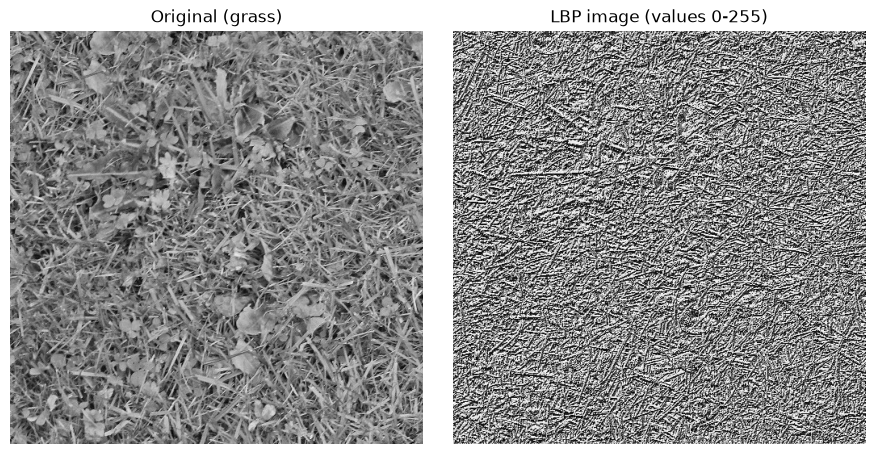

In [28]:
print("Same size as the original:", img.shape == lbp.shape)
print("Top-left 5x5 corner of the LBP image:\n", lbp[:5, :5])

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("Original (grass)"); ax[0].axis("off")
ax[1].imshow(lbp, cmap="gray"); ax[1].set_title("LBP image (values 0-255)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 3. Compute the histogram of the LBP image

In [29]:
def lbp_histogram(lbp_image, normalize=True):
    # Count how often each of the 256 LBP codes appears in the LBP image.
    hist = np.bincount(lbp_image.ravel(), minlength=256).astype(np.float64)
    if normalize:
        hist /= hist.sum()          # share of pixels instead of counts, so images of different sizes can be compared
    return hist

hist = lbp_histogram(lbp)
counts = lbp_histogram(lbp, normalize=False)
print(f"{len(hist)} bins, sum of shares = {hist.sum():.3f}, sum of counts = {counts.sum():.0f} (= {img.size} pixels)")

top = np.argsort(hist)[::-1][:5]
for c in top:
    print(f"  code {c:3d} ({c:08b}): {hist[c]:.1%} of the pixels")
print("Same as np.histogram:", np.array_equal(counts, np.histogram(lbp, bins=256, range=(0, 256))[0]))

256 bins, sum of shares = 1.000, sum of counts = 262144 (= 262144 pixels)
  code 255 (11111111): 6.2% of the pixels
  code   0 (00000000): 5.7% of the pixels
  code 240 (11110000): 1.6% of the pixels
  code 135 (10000111): 1.6% of the pixels
  code  60 (00111100): 1.6% of the pixels
Same as np.histogram: True


## 4. Plot the histogram
- and explain what it represents in terms of the texture features of the image.

Uniform codes: 58 of 256, covering 71.1% of the pixels


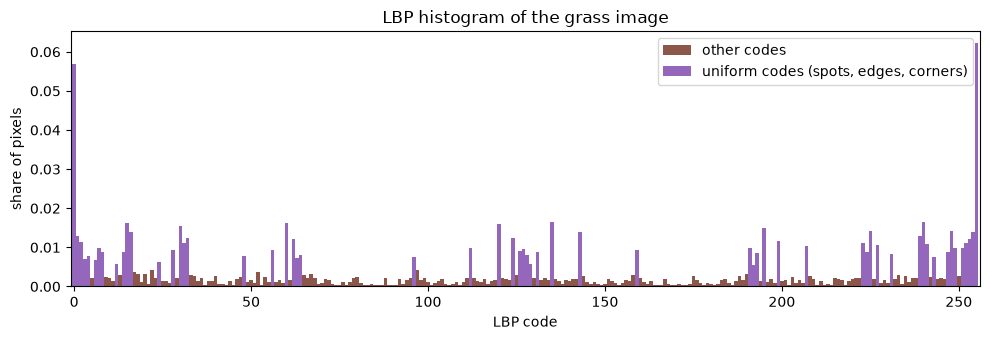

In [30]:
def transitions(code):
    # Number of 0->1 and 1->0 changes when going once around the 8 bits
    bits = [(code >> i) & 1 for i in range(8)]
    return sum(bits[i] != bits[(i + 1) % 8] for i in range(8))

uniform = np.array([transitions(c) <= 2 for c in range(256)])
print(f"Uniform codes: {uniform.sum()} of 256, covering {hist[uniform].sum():.1%} of the pixels")

codes = np.arange(256)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(codes[~uniform], hist[~uniform], width=1, color="C5", label="other codes")
ax.bar(codes[uniform], hist[uniform], width=1, color="C4", label="uniform codes (spots, edges, corners)")
ax.set_xlim(-1, 256); ax.set_xlabel("LBP code"); ax.set_ylabel("share of pixels")
ax.set_title("LBP histogram of the grass image"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Apply your LBP function to at least three different grayscale images 
- (e.g., a natural scene, a texture, and a face image).

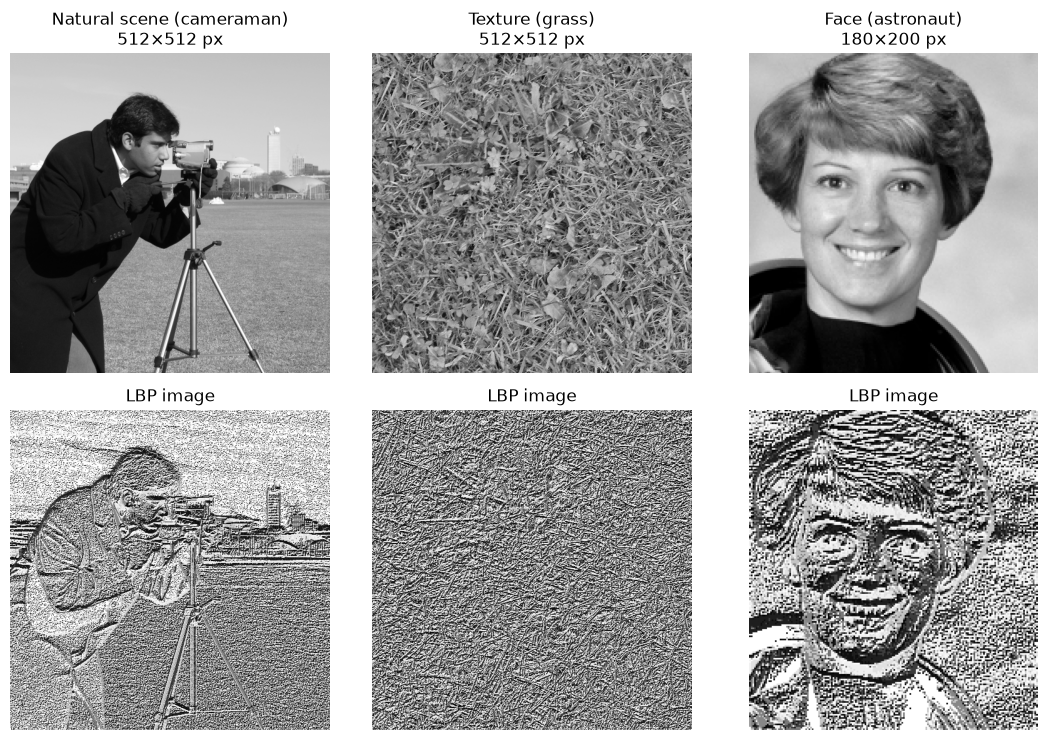

In [31]:
images = {
    "Natural scene (cameraman)": data.camera(),
    "Texture (grass)":           data.grass(),
    "Face (astronaut)":          (color.rgb2gray(data.astronaut())[20:220, 150:330] * 255).astype(np.uint8),
}
lbps = {name: compute_lbp(img) for name, img in images.items()}

fig, ax = plt.subplots(2, len(images), figsize=(11, 7.5))
for j, (name, img) in enumerate(images.items()):
    ax[0, j].imshow(img, cmap="gray"); ax[0, j].set_title(f"{name}\n{img.shape[1]}×{img.shape[0]} px"); ax[0, j].axis("off")
    ax[1, j].imshow(lbps[name], cmap="gray"); ax[1, j].set_title("LBP image"); ax[1, j].axis("off")
plt.tight_layout(); plt.show()

## 6.  Generate and compare the histograms of the LBP images

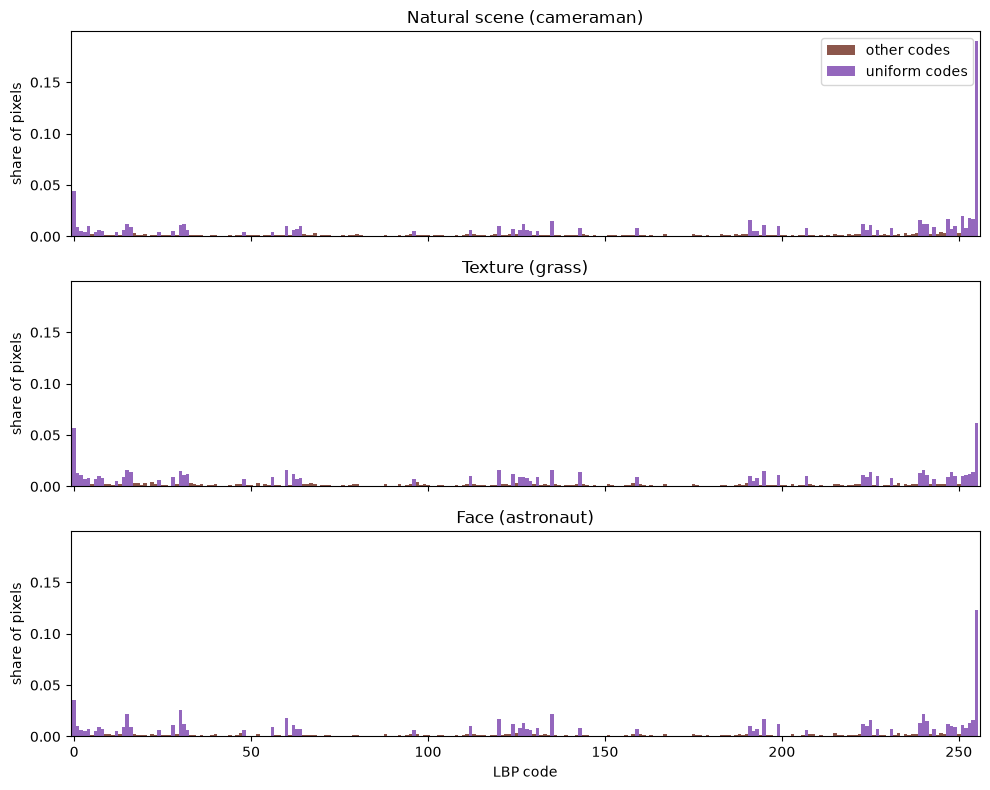

Image                       code 255  code 0  edges  uniform  entropy
Natural scene (cameraman)      19.0%    4.5%   9.4%    73.6%     6.47
Texture (grass)                 6.2%    5.7%  12.6%    71.1%     6.98
Face (astronaut)               12.3%    3.5%  16.0%    75.4%     6.69
Natural scene (cameraman)   code-255 pixels with an equal neighbour: 78%
Texture (grass)             code-255 pixels with an equal neighbour: 14%
Face (astronaut)            code-255 pixels with an equal neighbour: 73%


In [32]:
hists = {name: lbp_histogram(l) for name, l in lbps.items()}

fig, ax = plt.subplots(len(hists), 1, figsize=(10, 8), sharex=True, sharey=True)
for a, (name, h) in zip(ax, hists.items()):
    a.bar(codes[~uniform], h[~uniform], width=1, color="C5", label="other codes")
    a.bar(codes[uniform], h[uniform], width=1, color="C4", label="uniform codes")
    a.set_title(name); a.set_ylabel("share of pixels")
ax[0].legend(); ax[-1].set_xlabel("LBP code"); ax[-1].set_xlim(-1, 256)
plt.tight_layout(); plt.show()

ones = np.array([bin(c).count("1") for c in range(256)])     # number of brighter neighbours per code
edge_codes = uniform & (ones == 4)                            # half bright, half dark = straight edge

def entropy(h):
    p = h[h > 0]
    return -(p * np.log2(p)).sum()                            # 0 = one pattern only, 8 = all 256 equally

print(f"{'Image':<27}{'code 255':>9}{'code 0':>8}{'edges':>7}{'uniform':>9}{'entropy':>9}")
for name, h in hists.items():
    print(f"{name:<27}{h[255]:>9.1%}{h[0]:>8.1%}{h[edge_codes].sum():>7.1%}{h[uniform].sum():>9.1%}{entropy(h):>9.2f}")

# Where does code 255 come from? Share of code-255 pixels with at least one EQUAL neighbour
for name, img in images.items():
    H, W = img.shape
    p = np.pad(img.astype(int), 1, mode="edge")
    equal = np.zeros((H, W), bool)
    for dy, dx in [(0, 1), (-1, 1), (-1, 0), (-1, -1), (0, -1), (1, -1), (1, 0), (1, 1)]:
        equal |= p[1+dy:H+1+dy, 1+dx:W+1+dx] == img
    print(f"{name:<27} code-255 pixels with an equal neighbour: {equal[lbps[name] == 255].mean():.0%}")